# makemore_batchnorm


We'll continue optimizing the code from the previous lesson.

Note on Comments:
For code carried over from the last lesson, I will use multi-line comments (""") to distinguish new notes from the older ones. For entirely new cells added in this lesson, I will stick to standard single-line comments (#).

In [1]:
# import module
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read file
words = open('../names.txt', 'r').read().splitlines()

In [3]:
# utility functions
from string import ascii_lowercase
stoi = {c:i+1 for i, c in enumerate(ascii_lowercase)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}
vocab_size = len(itos)

In [4]:
# build and split the dataset
block_size = 3

def build_dataset(words):  
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])        # 80% training set
Xdev, Ydev = build_dataset(words[n1:n2])    # 10% dev set
Xte, Yte = build_dataset(words[n2:])        # 10% test set

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# MLP (parameters)
g = torch.Generator().manual_seed(2147483647)

emb_dim = 10    # dimension of embedding vectors
ns_num_h = 200    # the number of neurons in hidden layer

"""
The following methods adjust parameter initialization to boost performance 
and prevent critical training failures.
"""
"""
Fixing the Initial Loss (marked with `L` below)
(fix softmax confidently wrong)

Scale down output layer weights/biases near 0 to fix the artificially high initial loss.
Without this, standard normal init causes extreme logits (loss ~27). 
Scaling drops the initial loss to ~3.3 (since we have 27 characters, a uniform distribution 
yields an expected initial loss of exactly -log(1/27) ≈ 3.3). This saves early epochs 
from merely squashing weights and allows the model to focus on meaningful learning immediately.

Note on leaf vs. non-leaf nodes:
Leaf nodes have gradients (`.grad`) but no gradient function (.grad_fn).
Non-leaf nodes have a gradient function but do not retain gradients. 
Therefore, we update parameters via `tensor.data` to perform in-place operations 
without breaking the autograd computation graph.
"""
"""
Preventing Dead Neurons (marked with `D` below)
(fix tanh layer woo saturated at init)

Because we use `tanh` in hidden layer,
its derivative is close to 0 as inputs approach infinity (|x| >= 3).
If initial W1 and B1 are too large, pre-activations blow up and gradients drop to near zero. 
When this happens, the neuron permanently stops updating during gradient descent (it "dies").
We fix this by scaling down W1 and B1 to keep initial values close to 0.

Note: An excessively high learning rate during training can also knock parameters 
far off the data manifold, leaving neurons permanently inactive (dead) because 
no training samples will ever hit them.
"""
"""
Xavier Initialization (Karpathy loosely calls it "Kaiming init")  (marked with `X` below)

`X @ W1` scales variance by `fan_in`, risking activation explosion.
Fix: Scale std to 1/sqrt(fan_in) to maintain input/output variance.
Gain: Multiply by 5/3 to compensate for the `tanh` squashing effect ("semi-principled").
Note: True Kaiming (2015) uses sqrt(2/fan_in) to offset ReLU's 50% dead zone. 
Without the sqrt(2) and paired with `tanh`, this belongs to the Xavier family.

This adjustment is for:
Scale pre-activations to roughly match a standard normal distribution (mean ~0, var ~1).
This keeps values away from extremes, preventing `tanh` activations from saturating at -1 or 1.
Saturation drops gradients to zero, killing gradient descent and stopping learning (vanishing gradients).
"""
C = torch.randn((vocab_size, emb_dim),             generator=g, requires_grad=True)
W1 = torch.randn((block_size * emb_dim, ns_num_h), generator=g, requires_grad=True)
# W1.data *= 0.1    # D
W1.data *= (5/3) / (block_size * emb_dim)**0.5    # X
"""B1 is no longer needed; check the training loop for details."""
# B1 = torch.randn(ns_num_h,                         generator=g, requires_grad=True)
# B1.data *= 0.01    # D
W2 = torch.randn((ns_num_h, vocab_size),           generator=g, requires_grad=True)
W2.data *= 0.01    # L
B2 = torch.randn(vocab_size,                       generator=g, requires_grad=True)
B2.data *= 0    # L

"""for BatchNorm"""
"""
Scale (gamma) and Shift (beta) parameters:
These act as learnable weights and biases for the normalized outputs.
Why? A strict standard normal (mean 0, var 1) is great for init, but we shouldn't constrain the model to it forever.
As backprop optimizes the loss, it needs the flexibility to shift and scale these distributions.
These two parameters restore that adjustment capability.
"""
bnscale = torch.ones((1, ns_num_h),  requires_grad=True)
bnshift = torch.zeros((1, ns_num_h), requires_grad=True)

"""
These two variables track the BatchNorm running stats (mean and variance).
"""
bnmean_running = torch.zeros(1, ns_num_h)
bnstd_running = torch.ones(1, ns_num_h)


parameters = [C, W1, W2, B2, bnscale, bnshift]

print(sum(p.numel() for p in parameters))

12097


In [8]:
# use training set to train model
max_steps = 200000
batch_size = 32
lossi = []

for k in range(max_steps):
    
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)

    # forward pass
    emb = C[Xtr[ix]]

    # linear layer
    hpreact = emb.view(-1, block_size * emb_dim) @ W1 # + B1
    """
    We drop B1 because the subsequent BatchNorm subtracts the mean, 
    effectively canceling out the bias. After BN, B1's gradient becomes zero.
    """

    # batch norm layer
    """
    Batch Normalization
    
    Standardizes batch inputs per neuron at every step so pre-activations are roughly standard normal (mean ~0, var ~1).

    BatchNorm's implicit regularization:
    By normalizing across a batch, each neuron's output is perturbed by the entire batch 
    rather than just one sample. This batch-level noise acts as a form of regularization, 
    which actually boosts model generalization.
    
    Downside of BatchNorm:
    It couples data across the batch, which can introduce bizarre and hard-to-debug behaviors.
    Because of this, practitioners tend to avoid it in modern architectures (favoring LayerNorm, etc.).
    """
    bnmeani = hpreact.mean(dim=0, keepdim=True)
    bnstdi = hpreact.std(dim=0, keepdim=True)
    hpreact = bnscale * (hpreact - bnmeani) / bnstdi + bnshift
    """
    A full BatchNorm implementation adds a tiny constant (eps, e.g., 1e-5) 
    to the variance/std to prevent division by zero in edge cases on the previous line. 
    We omit it here because a zero std is practically impossible in this toy example.
    """

    """
    BatchNorm Running Statistics (for inference)

    Training: normalize with the CURRENT BATCH's per-feature mean/std.
    Inference: batch may be size 1 (single-sample inference) — batch stats degenerate
    (std = 0/NaN), so we must use statistics of the whole TRAINING distribution instead.

    Solution: accumulate them DURING training (nearly free — batch stats are already computed):
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani   # EMA (Exponential Moving Average)
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi
    Each batch stat is a consistent estimate (mean exactly unbiased, std approximately unbiased)
    of the population stat; the EMA is a weighted
    average of all past stats (weights decay 0.999^k, effective memory ≈ 1000 steps), which
    smooths the noise. Once training converges, the distribution is stationary → EMA ≈ population
    mean/std (by the law of large numbers).
    - The update runs under `torch.no_grad()`: it's bookkeeping, NOT part of the autograd graph.
    - Init values 0/1 match the standard normal init prior; they wash out exponentially (0.999^t),
    so the exact choice hardly matters for long training.
    - At inference (split_loss / sampling): use the running stats as fixed constants, never the
    current input's own stats.
    - Alternative: calibrate once with a full training-set forward pass (more exact, but costs
    an extra pass and requires training data at model finalization). Running stats are the
    production standard — nn.BatchNorm1d does exactly this internally.
    """
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # non-linearity layer
    hl = torch.tanh(hpreact)    # hidden layer (activation function)
    logits = hl @ W2 + B2    # output layer (logits, linear)
    loss = F.cross_entropy(logits, Ytr[ix])    # loss

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += p.grad * -(lr := 0.1 if k < 100000 else 0.01)

    # monitor
    if k % 10000 == 0:
        print(f'{k:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


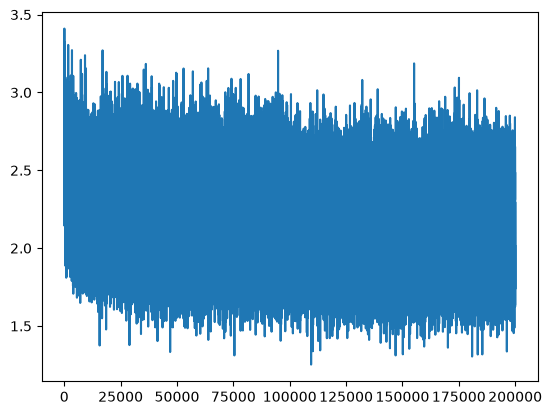

In [9]:
plt.plot(lossi)

In [10]:
# Manually calibrate the BatchNorm's mean and std,
# then freeze them to calculate the loss (and for future inference).
# Actually, the statistics here is computed for comparison;
# the final eval uses running stats instead.
with torch.no_grad():
    emb = C[Xtr]
    hpreact = emb.view(-1, block_size * emb_dim) @ W1 # + B1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(dim=0, keepdim=True)
    bnstd = hpreact.std(dim=0, keepdim=True)

# In practice, we rarely calibrate manually these two statistics.
# Instead, we track running stats (mean/std) on the fly during training with minimal overhead.
# Recomputing over the entire dataset later is too slow, risks OOM (Out of Memory), 
# and fails entirely if the training data becomes inaccessible/archived.

In [11]:
# evaluate the model and adjust hyperparameters
@torch.no_grad()
def splits_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x]
    hpreact = emb.view(-1, block_size * emb_dim) @ W1 # + B1
    # hpreact = bnscale * (hpreact - bnmean) / bnstd + bnshift
    hpreact = bnscale * (hpreact - bnmean_running) / bnstd_running + bnshift
    hl = torch.tanh(hpreact)
    logits = hl @ W2 + B2
    loss = F.cross_entropy(logits, y)
    print(f"{split}: loss: {loss:.4f}")
    return loss

tr_loss = splits_loss('train')
dev_loss = splits_loss('dev')

train: loss: 2.0674
dev: loss: 2.1057


**loss log**

**original**:
- train    2.1280
- val/dev  2.1642

**fix softmax confidently wrong**:
- train    2.0696
- val/dev  2.1311

**fix tanh layer too saturated at init**:
- train    2.0579
- val/dev  2.1137

**Xavier init**
- train    2.0377
- val/dev  2.1070

**add batch norm layer**
- train    2.0674
- val/dev  2.1057

In [12]:
# sample from model
g = torch.Generator().manual_seed(2147483647 + 10)

with torch.no_grad():
    for _ in range(10):
        outs = []
        context = [0] * block_size
        while True:
            emb = C[torch.tensor([context])]
            hpreact = emb.view(-1, block_size * emb_dim) @ W1
            hpreact = bnscale * (hpreact - bnmean_running) / bnstd_running + bnshift
            hl = torch.tanh(hpreact)
            logits = hl @ W2 + B2
            probs = torch.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g)
            outs.append(itos[ix.item()])
            context = context[1:] + [ix]
            if ix == 0: break
        print(''.join(outs))

carlah.
amorie.
khi.
mri.
reity.
salaysie.
mahnen.
delynn.
jareei.
ner.


## What's next (not covered here)

Karpathy's lecture continues with two parts:

1. **PyTorchifying**: wraps the manual code into classes (`Linear`, `BatchNorm1d`, `Tanh`)
   that mimic the `nn.Module` API — an imitation of PyTorch's own `nn` module.
2. **A deeper network (4 hidden layers)**: where BatchNorm's real power shows —
   a deep net without BN dies from tanh saturation; with BN it trains healthily,
   and per-layer pre-activation histograms stay roughly standard normal throughout.

We stopped here by design:
- The class-wrapping is mimicry of `nn.Module`; later lectures (Build GPT) use the real
  `nn.Linear` / `nn.BatchNorm1d` directly — better to learn the real thing there.
- To see/experiment: watch the lecture
  (corresponding to cells 12–20 of Karpathy's `makemore_part3_bn.ipynb`)
  and try the deeper network with `nn.Linear` + `nn.BatchNorm1d` + `nn.Sequential` (~20 lines).

**Note**: In fact, I still hand-rolled an nn.Module-like class from scratch; see Lec06 for details.